# Finding PI

### The Monte Carlo Approach

Before trying this with machine learning, let us first use the Monte Carlo method for estimating $\pi$.
In simple words, whenever a computer algorithm uses repeated random sampling to generate a numerical answer, we can call it a **Monte Carlo simulation**.

The concept is simple: imagine randomly tossing darts at a dartboard mounted inside a square. If the darts are random enough, then the points are approximately uniformly distributed over the square. The fraction of points falling inside a region should then be proportional to the area of that region.

For a circle of radius $r$ placed inside a square of side length $2r$, we have

$$
\frac{\text{area of circle}}{\text{area of square}}
=
\frac{\pi r^2}{(2r)^2}
=
\frac{\pi}{4}.
$$

Therefore,

$$
\pi \approx 4 \times \frac{\text{number of points inside the circle}}{\text{total number of points}}.
$$


Estimated value of PI: 3.1492


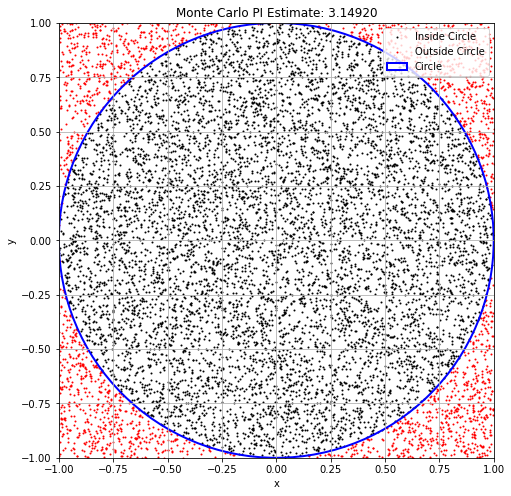

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Number of random points to throw inside the square.
# Larger N usually gives a better Monte Carlo estimate of pi.
N = 10000

# Generate random x and y coordinates in the square [-1, 1] x [-1, 1].
# np.random.uniform(-1, 1, N) gives N random numbers uniformly between -1 and 1.
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# A point (x, y) is inside the unit circle if
#
#     x^2 + y^2 <= 1.
#
# This creates a Boolean array: True for points inside the circle, False otherwise.
circled = x**2 + y**2 <= 1

# Estimate pi using the area ratio:
#
#     pi ≈ 4 * fraction of points inside the unit circle.
pi_val = 4 * np.sum(circled) / N

print(f"Estimated value of PI: {pi_val}")

# Plotting
plt.figure(figsize=(8, 8))

# Points inside the circle in black.
plt.scatter(x[circled], y[circled], color='black', s=1, label='Inside Circle')

# Points outside the circle in red.
plt.scatter(x[~circled], y[~circled], color='red', s=1, label='Outside Circle')

# Draw the circle outline for reference.
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linewidth=2, label='Circle')
plt.gca().add_artist(circle)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"Monte Carlo PI Estimate: {pi_val:.5f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


### The Machine Learning Approach

Now let us solve the same problem using a small neural network.

Here the neural network is **not directly learning the number $\pi$**. Instead, it is learning a classification rule:

$$
(x,y) \longmapsto \text{inside circle or outside circle}.
$$

Once the model has learned this rule, we can sample many points in the square, ask the model which points are inside the circle, and then estimate $\pi$ from the predicted area fraction.

So the machine learning problem here is:

$$
\text{learn the circular decision boundary from examples.}
$$

Let us first import the required libraries.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import copy

# PyTorch imports.
# torch is the main library, nn contains neural-network layers,
# and DataLoader/TensorDataset help us create mini-batches.
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

# torchinfo gives a convenient model summary.
# In some Colab environments, torchinfo may need to be installed first.
# If torchinfo is unavailable, we will simply print the model instead.
try:
    from torchinfo import summary
except ImportError:
    summary = None

# For reproducibility.
# This makes the random numbers the same each time we run the notebook.
np.random.seed(42)
torch.manual_seed(42)


- **Main Strategy:** Remember that machine learning is basically learning by example. Here we first generate random points inside the square $[-1,1]\times[-1,1]$ and label them as $1$ or $0$ depending on whether or not the points are inside the circle.

In [3]:
# Generate the training data.
# Each point has two coordinates: x and y.
# Therefore X_data has shape (N, 2).
N = 10000
X_data = np.random.uniform(-1, 1, (N, 2)).astype(np.float32)

# Create labels using the exact circle rule.
# Label 1 means the point is inside the unit circle.
# Label 0 means the point is outside the unit circle.
y_data = ((X_data[:, 0]**2 + X_data[:, 1]**2) <= 1).astype(np.float32)

# Convert NumPy arrays into PyTorch tensors.
# PyTorch models work with tensors rather than NumPy arrays.
X_tensor = torch.tensor(X_data)

# unsqueeze(1) changes the shape from (N,) to (N, 1).
# This matches the neural network output shape, which will also be (N, 1).
y_tensor = torch.tensor(y_data).unsqueeze(1)

# Put features and labels together into one dataset object.
dataset = TensorDataset(X_tensor, y_tensor)

# Split into training and validation sets.
# The model learns from the training set.
# The validation set is used to check how well the model generalizes.
val_size = int(0.2 * N)
train_size = N - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoader creates mini-batches.
# batch_size=64 means the model sees 64 points at a time during training.
# shuffle=True randomly changes the order of training data each epoch.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# For validation, we do not need shuffling.
# A larger batch size is fine because no gradient update is performed during validation.
val_loader = DataLoader(val_dataset, batch_size=512)


- Next step is to define the network or model. Since the input is a point $(x,y)$, the input dimension is $2$. Since the output is the probability of being inside the circle, the output dimension is $1$.


In [4]:
# Define the model.
# This is a small feed-forward neural network.
# The model takes a 2D point (x, y) as input and returns one number between 0 and 1.

class PiNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            # First linear layer: 2 input features -> 32 hidden neurons.
            nn.Linear(2, 32),

            # Sigmoid is a nonlinear activation function.
            # Without nonlinearities, the model could only learn a straight-line boundary.
            nn.Sigmoid(),

            # Second hidden layer: 32 hidden neurons -> 32 hidden neurons.
            nn.Linear(32, 32),
            nn.Sigmoid(),

            # Final layer: 32 hidden neurons -> 1 output value.
            nn.Linear(32, 1),

            # Final sigmoid turns the output into a number between 0 and 1.
            # We interpret this as the probability that the point is inside the circle.
            nn.Sigmoid()
        )

    def forward(self, x):
        # The forward method defines how input data pass through the network.
        return self.net(x)


model = PiNet()

# Show a summary of the model.
# If torchinfo is available, we use summary(model).
# Otherwise, we print the model and count parameters manually.
if summary is not None:
    summary(model)
else:
    print(model)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Trainable parameters:", total_params)

- Setting up the loss function, optimizer, and training-history containers.


In [5]:
# Binary Cross Entropy loss is commonly used for binary classification.
# Here the target is either 0 or 1:
#   1 = inside the circle
#   0 = outside the circle
criterion = nn.BCELoss()

# Adam is an optimizer. It updates the model parameters using gradients.
# lr is the learning rate, controlling the size of each update step.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Maximum number of training epochs.
# We redefine this later in the training cell, but keeping it here makes the setup visible.
epochs = 200

# patience controls early stopping.
# If validation loss does not improve for this many epochs, training stops.
patience = 15

# Lists for tracking how the model behaves during training.
pi_history = []
val_loss_history = []
decision_boundary_snapshots = []


In [6]:
# Helper functions for estimating pi and plotting the decision boundary.


def estimate_pi(model, val_loader):
    """
    Estimate pi using the trained model.

    The model predicts whether validation points are inside or outside the circle.
    If the model says a fraction f of points are inside the circle, then

        pi ≈ 4 f.

    This mirrors the Monte Carlo area-ratio argument.
    """
    model.eval()
    all_preds = []

    # no_grad means we are only evaluating the model, not training it.
    with torch.no_grad():
        for xb, _ in val_loader:
            # model(xb) returns probabilities between 0 and 1.
            # We convert probability > 0.5 into class 1, otherwise class 0.
            preds = model(xb) > 0.5
            all_preds.append(preds)

    # Concatenate predictions from all validation batches.
    # The mean is the predicted fraction of points inside the circle.
    return 4 * torch.cat(all_preds).float().mean().item()


def plot_decision_boundary(model, epoch):
    """
    Plot the region that the neural network believes is inside the circle.

    We create a dense grid of points in the square [-1, 1] x [-1, 1],
    evaluate the model on all grid points, and then plot the predicted region.
    """
    model.eval()

    # Create a grid of points covering the square.
    grid_x, grid_y = np.meshgrid(
        np.linspace(-1, 1, 200),
        np.linspace(-1, 1, 200)
    )

    # Convert the grid into a list of 2D points: (x, y).
    grid_points = torch.tensor(
        np.c_[grid_x.ravel(), grid_y.ravel()],
        dtype=torch.float32
    )

    # Evaluate the model on the grid.
    with torch.no_grad():
        preds = model(grid_points).numpy().reshape(grid_x.shape)

    plt.figure(figsize=(6, 6))

    # The contour shows the model's predicted inside/outside regions.
    # Values below 0.5 are outside; values above 0.5 are inside.
    plt.contourf(
        grid_x,
        grid_y,
        preds,
        levels=[0, 0.5, 1],
        alpha=0.3,
        colors=['red', 'black']
    )

    # Plot validation points on top of the learned decision region.
    X_val_np = val_dataset[:][0].numpy()
    y_val_np = val_dataset[:][1].numpy()

    plt.scatter(
        X_val_np[y_val_np[:, 0] == 1][:, 0],
        X_val_np[y_val_np[:, 0] == 1][:, 1],
        s=1,
        c='black',
        label='Inside circle'
    )
    plt.scatter(
        X_val_np[y_val_np[:, 0] == 0][:, 0],
        X_val_np[y_val_np[:, 0] == 0][:, 1],
        s=1,
        c='red',
        label='Outside circle'
    )

    plt.title(f"Epoch {epoch+1}: Decision Boundary (π ≈ {pi_history[-1]:.6f})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal')
    plt.grid(True)
    plt.legend(markerscale=5)
    plt.show()


- Let us now train the `PiNet` model.

During training, the model gradually changes its weights so that its predictions match the labels. We monitor the validation loss and keep a copy of the best model state in memory.

Epoch 10: Val Loss = 0.5005, π ≈ 4.000000
Epoch 20: Val Loss = 0.4870, π ≈ 4.000000
Epoch 30: Val Loss = 0.2173, π ≈ 3.464000


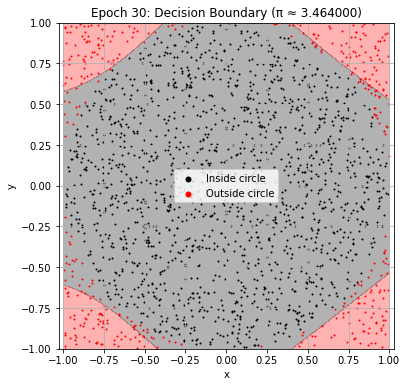

Epoch 40: Val Loss = 0.1147, π ≈ 3.218000
Epoch 50: Val Loss = 0.0938, π ≈ 3.192000
Epoch 60: Val Loss = 0.0782, π ≈ 3.244000


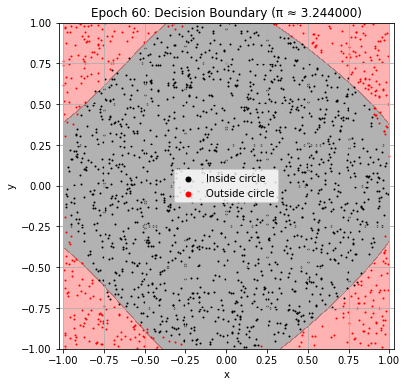

Epoch 70: Val Loss = 0.0701, π ≈ 3.232000
Epoch 80: Val Loss = 0.0638, π ≈ 3.240000
Epoch 90: Val Loss = 0.0582, π ≈ 3.222000


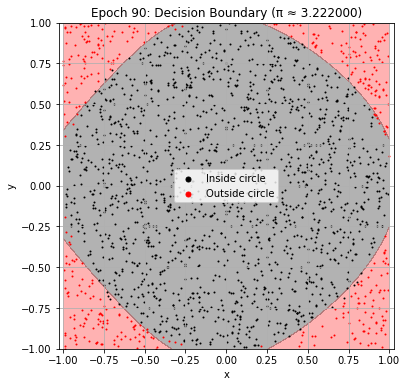

Epoch 100: Val Loss = 0.0540, π ≈ 3.218000
Epoch 110: Val Loss = 0.0500, π ≈ 3.216000
Epoch 120: Val Loss = 0.0465, π ≈ 3.202000


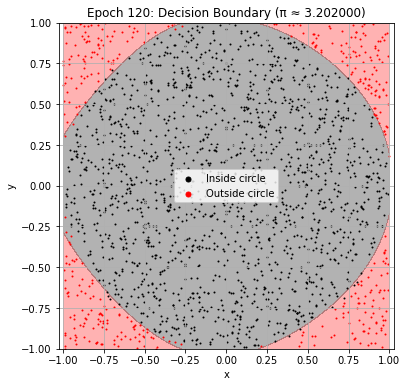

Epoch 130: Val Loss = 0.0446, π ≈ 3.200000
Epoch 140: Val Loss = 0.0441, π ≈ 3.172000
Epoch 150: Val Loss = 0.0381, π ≈ 3.198000


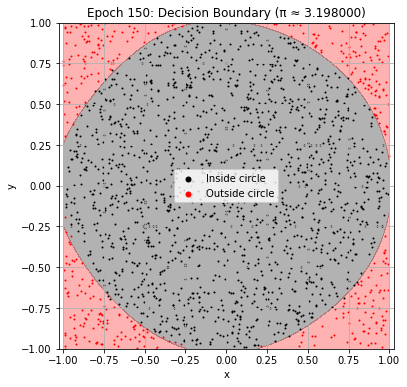

Epoch 160: Val Loss = 0.0373, π ≈ 3.180000
Epoch 170: Val Loss = 0.0353, π ≈ 3.242000
Epoch 180: Val Loss = 0.0328, π ≈ 3.194000


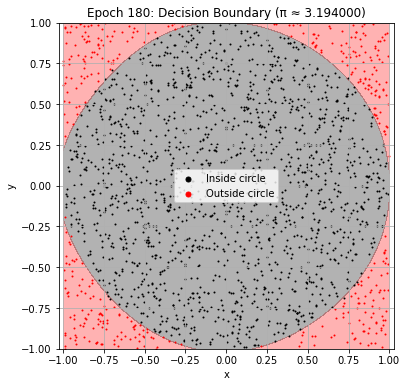

Epoch 190: Val Loss = 0.0324, π ≈ 3.184000
Epoch 200: Val Loss = 0.0292, π ≈ 3.214000
Epoch 210: Val Loss = 0.0277, π ≈ 3.188000


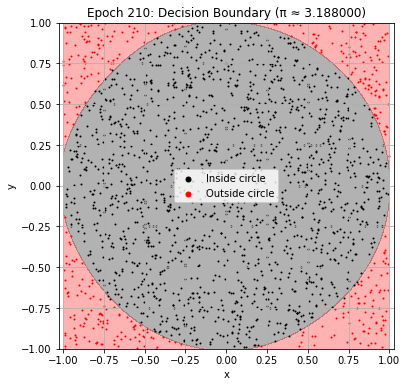

Epoch 220: Val Loss = 0.0267, π ≈ 3.224000
Epoch 230: Val Loss = 0.0252, π ≈ 3.208000
Epoch 240: Val Loss = 0.0245, π ≈ 3.216000


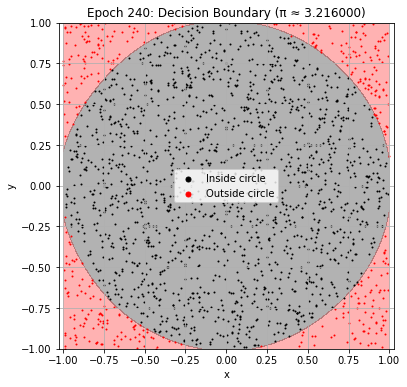

Epoch 250: Val Loss = 0.0235, π ≈ 3.208000
Epoch 260: Val Loss = 0.0249, π ≈ 3.176000
Epoch 270: Val Loss = 0.0222, π ≈ 3.212000


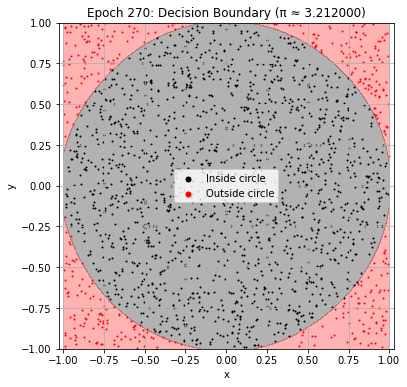

Epoch 280: Val Loss = 0.0226, π ≈ 3.222000
Epoch 290: Val Loss = 0.0225, π ≈ 3.174000
Epoch 300: Val Loss = 0.0202, π ≈ 3.206000


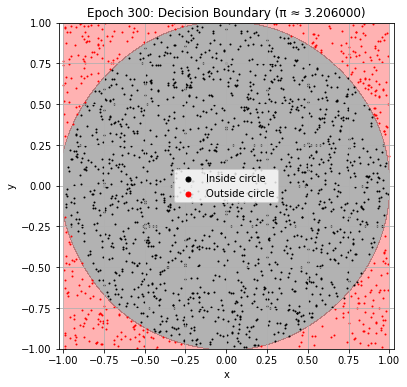

Epoch 310: Val Loss = 0.0240, π ≈ 3.182000
Epoch 320: Val Loss = 0.0186, π ≈ 3.200000
Epoch 330: Val Loss = 0.0192, π ≈ 3.190000


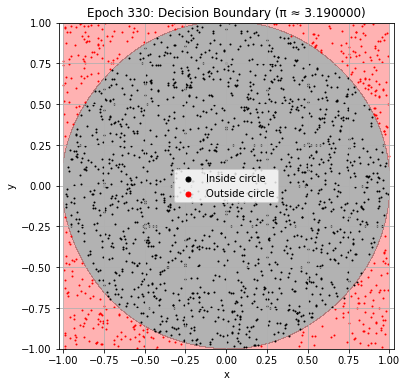

Epoch 340: Val Loss = 0.0177, π ≈ 3.200000
Early stopping!


In [7]:
# Train loop with visual updates.
# One epoch means one full pass through the training dataset.
epochs = 600
patience = 12

# best_val_loss stores the lowest validation loss seen so far.
best_val_loss = float('inf')

# best_epoch stores the epoch number where the validation loss was best.
best_epoch = 0

# wait counts how many epochs have passed without improvement.
wait = 0

# This will store a copy of the best model parameters.
best_model_state = None

for epoch in range(epochs):


    # Training phase

    model.train()

    # Go through the training data mini-batch by mini-batch.
    for xb, yb in train_loader:

        # Clear gradients from the previous step.
        optimizer.zero_grad()

        # Forward pass: compute model predictions.
        preds = model(xb)

        # Compare predictions with true labels.
        loss = criterion(preds, yb)

        # Backward pass: compute gradients.
        loss.backward()

        # Update model parameters using the optimizer.
        optimizer.step()


    # Validation phase

    model.eval()
    val_loss = 0

    # During validation, we do not update weights.
    with torch.no_grad():
        for xb, yb in val_loader:
            val_loss += criterion(model(xb), yb).item()

    # Average validation loss over all validation batches.
    val_loss /= len(val_loader)
    val_loss_history.append(val_loss)

    # Use the current model to estimate pi.
    pi_est = estimate_pi(model, val_loader)
    pi_history.append(pi_est)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Val Loss = {val_loss:.4f}, π ≈ {pi_est:.6f}")


    # Early stopping logic

    # If the validation loss improves, keep this model as the best model.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch

        # IMPORTANT:
        # We use copy.deepcopy so that we really store the best weights.
        # Otherwise, the stored state could keep changing as the model trains.
        best_model_state = copy.deepcopy(model.state_dict())

        wait = 0
    else:
        # If validation loss did not improve, increase the wait counter.
        wait += 1

        # Stop training if validation loss has not improved for 'patience' epochs.
        if wait >= patience:
            print("Early stopping!")
            break

    # Plot the learned decision boundary every 30 epochs.
    # This helps us see how the network gradually learns the circle.
    if (epoch + 1) % 30 == 0:
        plot_decision_boundary(model, epoch)


- **Final Plot:** Early stopping has now occurred, or training has reached the maximum number of epochs. We now load the best model found during training and inspect the result.



Best result at epoch 332: π ≈ 3.200000 (val_loss: 0.017568)


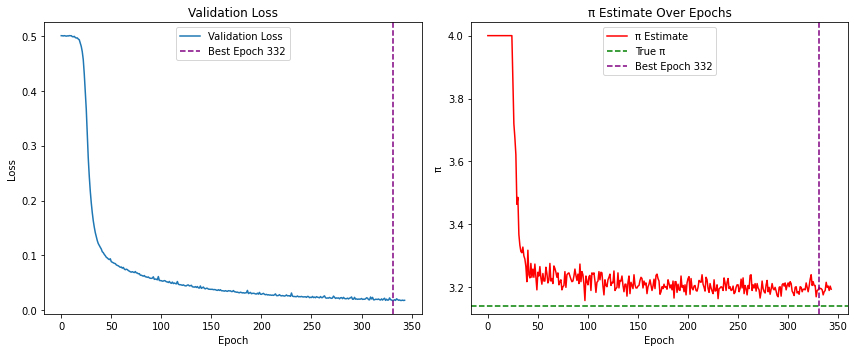

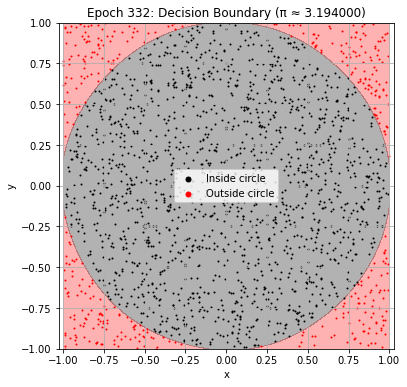

In [8]:
# Final plots after training.

# Load the best model parameters found during training.
# This is the model state corresponding to the lowest validation loss.
model.load_state_dict(best_model_state)

print(
    f"\nBest result at epoch {best_epoch+1}: "
    f"π ≈ {pi_history[best_epoch]:.6f} "
    f"(val_loss: {val_loss_history[best_epoch]:.6f})"
)

# Plot validation loss and pi estimate history.
plt.figure(figsize=(12, 5))

# Left panel: validation loss.
plt.subplot(1, 2, 1)
plt.plot(val_loss_history, label="Validation Loss")
plt.axvline(
    x=best_epoch,
    color='purple',
    linestyle='--',
    label=f'Best Epoch {best_epoch+1}'
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Validation Loss")

# Right panel: pi estimate over training.
plt.subplot(1, 2, 2)
plt.plot(pi_history, color='red', label="π Estimate")
plt.axhline(y=np.pi, color='green', linestyle='--', label="True π")
plt.axvline(
    x=best_epoch,
    color='purple',
    linestyle='--',
    label=f'Best Epoch {best_epoch+1}'
)
plt.xlabel("Epoch")
plt.ylabel("π")
plt.legend()
plt.title("π Estimate Over Epochs")

plt.tight_layout()
plt.show()

# Plot the decision boundary of the best model.
# Ideally, the black predicted region should look close to a circle.
plot_decision_boundary(model, best_epoch)
